# GPR in a Single Homogeneous Medium: Free-Space

In the context of wave propagation, a homogeneous free-space is the simplest medium to solve for. 
As such, in this notebook, we present a step-by-step guide for setting up simple problems with `elfe3D_GPR`. 

We demonstrate how to use the `Python` wrapper to set up problems that are solved by the `Fortran` core of `elfe3D_GPR`. 
Once solved, we illustrate some simple functions to post-process and visualize field results that are also a part 
of the Python wrapper.

## 1. Imports

The `Python` wrapper for `elfe3D_GPR` is simply `elfe3d_gpr_io`. It is installed from the repository root using `pip install -e .`. Once installation of the Fortran core as well as this IO wrapper is complete using the steps mentioned here (), we can proceed with importing and setting up the IO tools

In [ ]:
%matplotlib inline
import os
from pathlib import Path

# elfe3D_GPR inputs and model building
from elfe3d_gpr_io.inputs.survey import GPRSurvey

# elfe3D_GPR integrated mesh building and solver execution
from elfe3d_gpr_io.runner import ProjectPaths, run_tetgen, run_solver

# elfe3D_GPR output reading, postprocessing, and visualization
from elfe3d_gpr_io.outputs.fieldreader import AnalyticalLoader, ElfeLoader
from elfe3d_gpr_io.outputs.visualize   import (ReceiverLinePlot, 
                                               ReceiverLineErrorPlot,
                                               ReceiverLineCombined,
                                               ErrorHistogramPlot)

## 2. Paths and Platform configuration

As the current workflow of `elfe3D_GPR` involves:

1. A `Fortran` core solver,
2. `tetgen` meshing library, and
3. A `Python` IO wrapper,

it is essential to ensure that all three systems are found by the system and work together regardless of their own individual install path locations. As such, the `ProjectPaths` class (and hence the complete `runner` script) was created. 

`Windows` users can install `elfe3D_GPR` in their `WSL` (Windows Subsystems for Linux) while `Linux` users have native support.

### Linux-only and WSL guidance

- Linux-only users should set `use_wsl=False`, install `tetgen` and `mumps` in Linux, and ensure `elfe3d_gpr` is executable at `paths.exec_path()`.
- WSL users should keep `use_wsl=True`, install `tetgen` inside WSL, and rely on `runner.py` to convert Windows `Path` values to `/mnt/...` paths.
- For both workflows, verify `survey.io.poly_file` and `survey.io.base_dir` are correct before running the solver.
- Advanced users can use `run_custom_command(paths, command, cwd=..., use_wsl=...)` to override command execution.

In [ ]:
MASTER_PATH = (Path("..") / "elfe3D_GPR").resolve() # Base path variable, optional but convenient.

paths = ProjectPaths(
    master_dir = MASTER_PATH,   # Path where the elfe3D_GPR executable is located. Currently it is the same as repository root.
    exec_rel   = "",            # Relative path to find the executable. With the default installation it exists in the repository root, hence an empty string.
    use_wsl    = True,          # False if running the notebook from native Linux.
)

# Prints to verify that the paths are correct.
# print('Solver root:', MASTER_PATH)
# print('Executable:', paths.exec_path())


Solver root: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR
Executable: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


## 3: Generating the Geophysical Model using the Python I/O Wrapper

In this step we start building our geophysical model. As the example model here only has free-space, the focus of this example is to show the various input choices that exist to alter how the model is setup and run.

### IO class and functions

For simplicity, the `GPRSurvey` class was written to collect all relevant input information that will be used to create the simulation, such as the domain extents, materials, source, receivers, solver settings, and PML configuration.

Its `build()` function accepts all simulation input, and its `generate()` function generates most of the needed `elfe3D_GPR` input files. The rest of the input files are mesh files that will be created by `tetgen` in the next step.

### Physical conventions and modelling considerations

The coordinate system followed by `elfe3D_GPR` is the conventional cartesian system, with the air-ground interface at $z = 0$, upwards being $+z$-axis, while downwards into ground being $-z$-axis.

The current I/O implementation requires at least one earth layer, so the layer is set to match air properties exactly.


In [ ]:
# Frequency and wavelength definitions (optional to define before building the GPR survey information).

f    = 100e6        # only one frequency to be simulated [Hz]: can be extended to a list in a single run.
wave = 3e8 / f      # free-space wavelength for the same frequency [m], a simple approximate to manage dimensions and PML variables.


# Building the survey information using the `GPRSurvey.build()` function.

survey = GPRSurvey.build(

    # Name of the experiment, will also be used to create file and folder names for I/O.
    experiment_name = 'air_only', 

    # Base directory for the input and output files. The input files get created in base_dir/in, while outputs get created in base_dir/out_{experiment_name}.
    base_dir        = MASTER_PATH, 

    # Domain extents [in meters]. x_e and y_e are lateral extents, while z_e is the vertical extent. x_e currently has 1 m extra  to keep all receivers. 
    # wave/10 is a padding around the source to ensure enough of the near-field is captured before the PML starts.
    # As can be noticed, the domain is a very small box around the source and receivers, 
    # which is a strength from dense meshing from unstructured FEM.
    x_e = [-wave/10, 1 + wave/10],  
    y_e = [-wave/10,     wave/10],
    z_e = [-wave/10,     wave/10],

    # Material definition (air/free-space): Currently the air parameters can also be modified (but the flexibility might be removed in the future versions).
    air_eps_r = 1.0,      
    air_sigma = 1e-16,

    # Material definitions (layers of earth): Currently only one layer is needed (and that of free-space).
    # Layers can be simultaneously defined in lists as shown below, where each entry of the list corresponds to one layer.
    # These layer variables should have the same number of entries.
    layer_thicknesses = [wave/10],  # thin dummy layer required by current implementation (will be made more flexible in future versions).
    layer_eps_r       = [1.0],      # same as air
    layer_sigma       = [1e-16],    # same as air
    layer_mu_r        = [1.0],      # Non-magnetic
    layer_sigma_m     = [0.0],      # No magnetic losses

    # Source dipole definition: Currently only one source definition is possible, but the same source can have multiple frequencies. 
    # This is to allow wide-band simulations, like a real-world GPR system.
    # Note that with a wide spectrum, one mesh file with one specific discretization could struggle with accuracy.
    # In the thesis work () @TODO, it was studied how many `blocks` does a wide-band spectrum need to be divided into to allow accurate results over the 
    # entire spectrum.
    f_list              = [f],                  # List of frequencies.
    antenna_position    = [0.0, 0.0, 0.025],    # [x, y, z], 25 mm above the surface.
    source_type         = 6,                    # 6 corresponds to a flexible dipole definition. Use as default.
    current_direction   = 1,                    # 1 corresponds to x-direction, 2 to y-direction, and 3 to z-direction.
    num_segments        = 1,                    # Number of segments to divide the dipole source into. Gives more meshing flexibility, but not required for now.
    s_f                 = 250,                  # Source factor: How large the source dipole length is compared to free-space wavelength of the first frequency in the `f_list`.
    box_present         = False,                # @TODO: <To be deprecated> Box of fine mesh around the source: The feature was tested during the thesis (), but results were not promising.
    bh_f                = 1.0,                  # @TODO: <To be deprecated> Box factor: same as above.
    box_x               = [-1.0, 1.0],          # @TODO: <To be deprecated>
    # for `source_type`: Other types have fixed orientations including loops of current (from the original elfe3D code).

    # Receiver points definition: 
    # In lieu with GPR surveys, you can define receivers in three typical directions from the source direction:
    # 1) endfire (inline): location along the same direction as the source dipole axis
    # 2) broadside: location along the direction perpendicular to the source dipole axis
    # 3) oblique (at 45 degrees to the source)
    num_receivers_inline  = 48,
    num_receivers_endfire = 0, # @TODO: Fix naming of receiver lines.
    num_receivers_oblique = 0,

    # Solver parameters definition: elfe3D_GPR uses MUMPS to solve the system of equations once the FEM system is assembled.
    # The following parameters are passed to MUMPS solver directly. You can refer to the MUMPS documentation for 
    # more details on these parameters: () @TODO
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML definition: The Perfectly Matched layer (PML) used in elfe3D_GPR is the Uniaxial PML with an "Exact Reciprocal Decay" as the default type. 
    # You can find more details on the specifics of the PML implementation and the specific decay function here () @TODO.
    # Only 1 layer of heterogeneously distributed mesh elements is needed due to the Exact Reciprocal Decay implementation.
    num_pml_layers      = 1,        # Number of PML layers.
    pml_layer_thickness = wave/10,  # Thickness of the PML layer. With elfe3D_GPR, the PML layer can be very thin.
    pml_type            = 'lin',    # @TODO <To be deprecated>
    pml_decay_type      = 1,        # PML decay type: 1 corresponds to "Exact Reciprocal Decay", default and recommended. Others mentioned here () @TODO.

    least_samples_per_wavelength = 40,  # Dictates how big the mesh tetrahedra element edge lengths are. Recommended at least 10.
)

# Once the survey information is built into the right structures, the `survey.generate()` function creates the input files for the meshing and solver steps.
# The input files include the `.poly` files that are the input to `tetgen`. Hence, in the next step, `tetgen` is called to create the mesh files.
survey.generate()

# Prints to verify that the paths are correct for the input files generated by the I/O wrapper.
# print('poly :', survey.io.poly_file)
# print('inputs:', survey.io.input_dir)


## 4: Mesh generation with `tetgen`

TetGen converts the generated `.poly` file geometry into a tetrahedral mesh. This mesh is required by `elfe3D_GPR` so that the linear system of equations corresponding to the wave problem is adequately defined. The `.poly` file would typically be generated within the `in` folder in the `base_dir` directory.

The `run_tetgen()` function is a wrapper to call tetgen using python's subprocess and shlex modules from within the notebook.
This function is platform configuration-specific (currently supports WSL and untested Linux-only installs). In case the function struggles to work, you could:
1. either create the mesh files on your own by running tetgen from your terminal, or, 
2. modify the `run_tetgen` function in `elfe3d_gpr_io.runner` to be compatible with your platform.


In [8]:
run_tetgen(paths, survey.io.poly_file) # Passing the paths configuration survey's poly file location to make sure the right files are read and written in correct location.

Opening GPR_model_air_only.poly.
Delaunizing vertices...
Delaunay seconds:  0.002427
Creating surface mesh ...
Surface mesh seconds:  0.00121
Constrained Delaunay...
Constrained Delaunay seconds:  0.001779
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000151
Refining mesh...
Refinement seconds:  1.67411
Optimizing mesh...
Optimization seconds:  0.077419

Writing GPR_model_air_only.1.node.
Writing GPR_model_air_only.1.ele.
Writing GPR_model_air_only.1.face.
Writing GPR_model_air_only.1.edge.
Writing GPR_model_air_only.1.vtk.
Writing GPR_model_air_only.1.neigh.

Output seconds:  1.33617
Total running seconds:  3.09336

Statistics:

  Input points: 226
  Input facets: 118
  Input segments: 329
  Input holes: 0
  Input regions: 36

  Mesh points: 76132
  Mesh tetrahedra: 451595
  Mesh faces: 911280
  Mesh edges: 535816
  Mesh faces on facets: 56663
  Mesh edges on segments: 2357
  Steiner points inside domain: 48963
  Steiner points on face

Once complete, the mesh files are stored alongside the input files in the survey input directory.

## 5: Run the Fortran solver

Now, all inputs are generated, hence the `elfe3D_GPR` executable is ready to run. This is done simply by calling the `run_solver` function. This is also a very platform-specific function that can be modified, or the executable run standalone after the generation process.

In [9]:
run_solver(paths, survey) # Passing the paths configuration and survey object to make sure the right files are read and written.

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_air_only.                            
Your mesh has
       76132 Nodes
      451595 Elements
      535816 Edges (dof)
*************************************
Assembling connectivity arrays
Calculating interpolation coefficients
Obtaining model properties
*************************************
Source parameters:
 CSTYPE           6
 source-start coordinates:
  -1.4999999999999999E-004   0

Once the function completes its run, the output files are stored in `out_{experiment_name}` folder in the base directory.

## 6: Load solver results

To read and plot some results from `elfe3D_GPR`, the `outputs` module of the Python wrapper is useful. 

To start, the `ElfeLoader` reads the electric field information, from a given output receiver-line file. It can be used for quick plotting as will be soon shown.

In [4]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'     # Declaring which of the output files to read, as elfe3D_GPR contains separate electric and magnetic field output files.
# print('reading:', result_txt)

# Load the receiver-line electric field result from the solver output. Here we use the same number of endfire receivers as defined above.
ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR free-space',
    num_endfire = 48,   # matches num_receivers_inline above
).endfire() 
# The .endfire() function is used to make sure the data is read as a receiver line in the same direction as the output file stores.

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


r : 0.100 - 1.000 m   (48 receivers)


## 7: Load analytical reference solution for the free-space-only model.

As an analytical solution for the free-space GPR wave propagation exists, we have evaluated it with the same frequency, source assumed as a point source, with receivers in same configuration as defined in survey. The analytical solution can be loaded into the current notebook memory using the `AnalyticalLoader` class.

In [6]:
ANALYTICAL_DIR = (Path("..") / "data"/ "data_semi_analytical").resolve()    # Directory for where to find the analytical reference data.

# Loading the analytical equivalent to the simulation.
analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_air_100MHz_NR.csv'),
    label='analytical',
).endfire() 
# The .endfire() function is used to make sure the data is read as a receiver line in the same direction as the simulation.

## 8: Compare computed field to analytical reference

Once both the datasets are loaded, we can plot them. The I/O package has multiple small plotting classes that work with the loaded datasets. 

### 8.1. Plotting the base receiver-line data against analytical solution

The following `ReceiverLinePlot` is a simple first plotting function. This plot shows the computed endfire electric field together with the analytical reference. A close match indicates the solver correctly reproduces the air-only response.

Currently, only the plotting function exists per each visualization class. The plotting functions can accept multiple simulation data objects, hence the first `ef` argument is in a list.


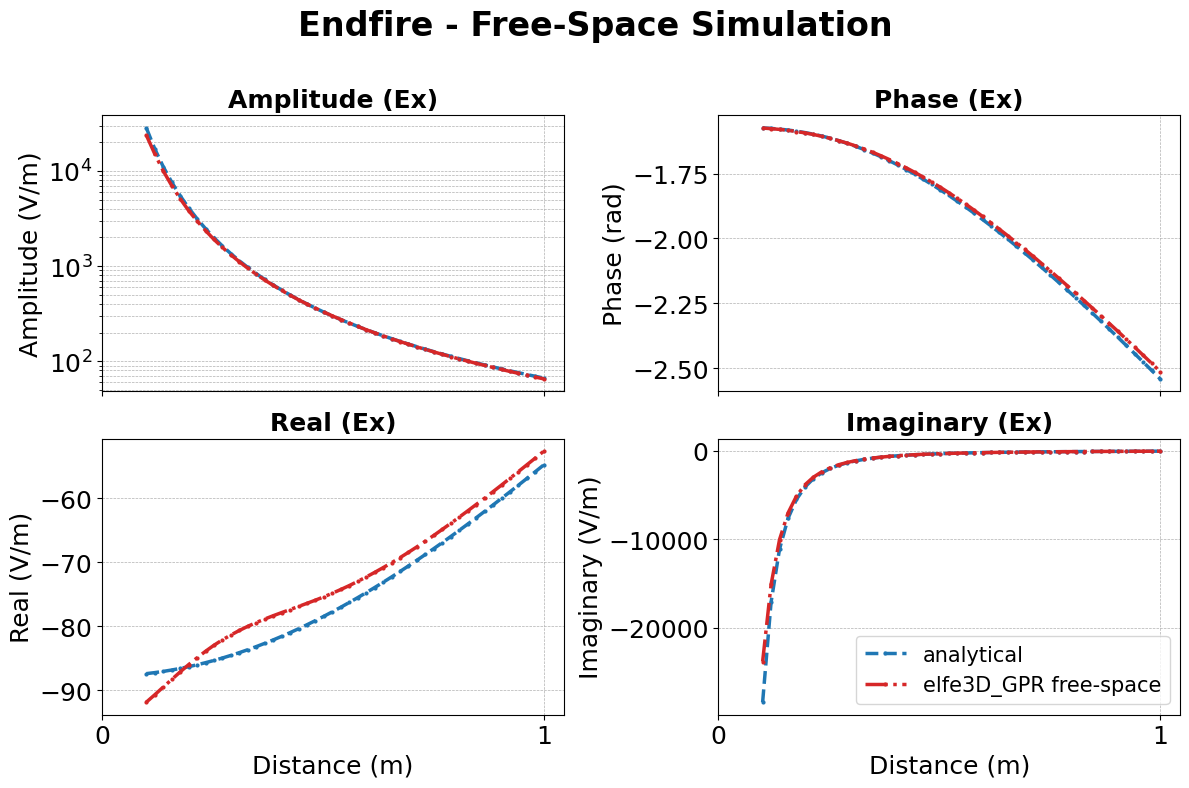

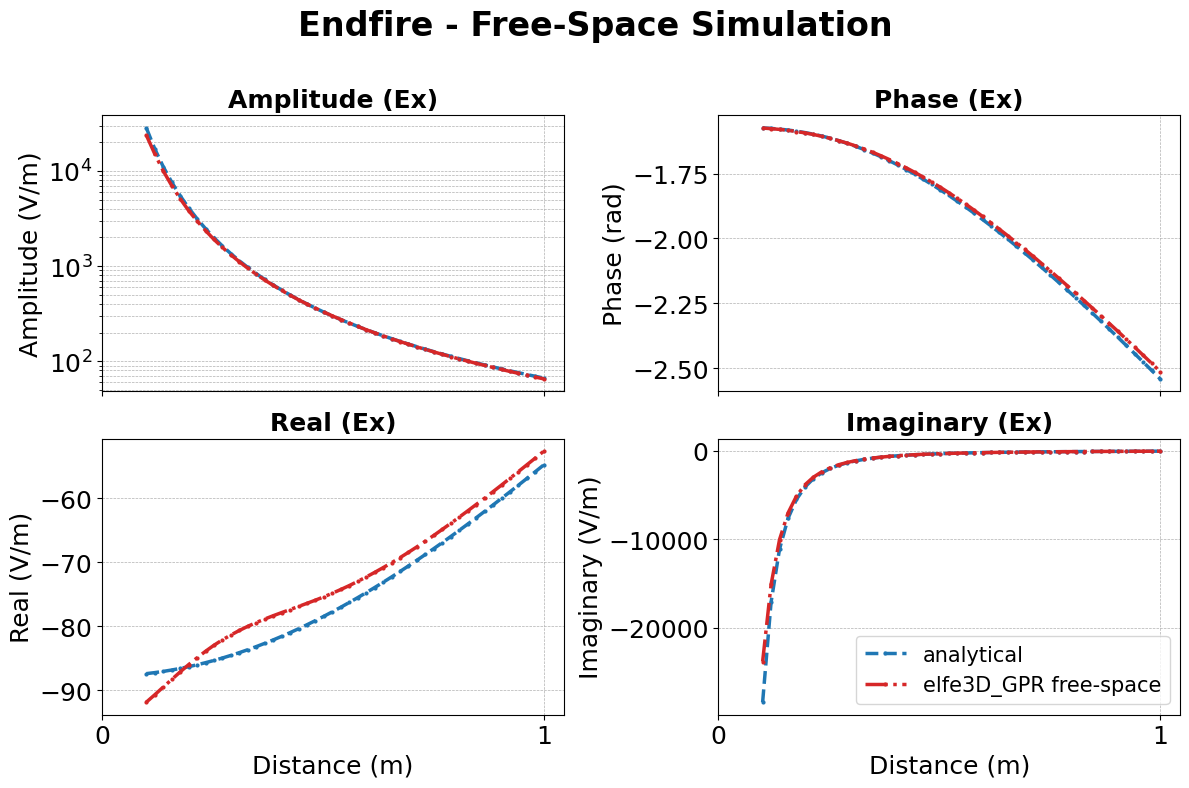

In [7]:
ReceiverLinePlot([analytical, ef],).plot(suptitle='Endfire - Free-Space Simulation')


It will be noticed that the real part of the `elfe3D_GPR` solution struggles to match the analytical solution, and that some error exists. While this might be discouraging, it is worth noting that the later examples with layered geophysical media show very good agreement to the semi-analytical solutions for layered GPR wave propagation even with `least_samples_per_wavelength` variable in the survey set between 10 and 20. This is an interesting outcome, that is not fully understood yet. 

For now, we move to the next useful plotting function, the error plots.

### 8.2 Error plot and quality check

This following plot highlights the difference between the computed result and the analytical reference across the receiver line. 

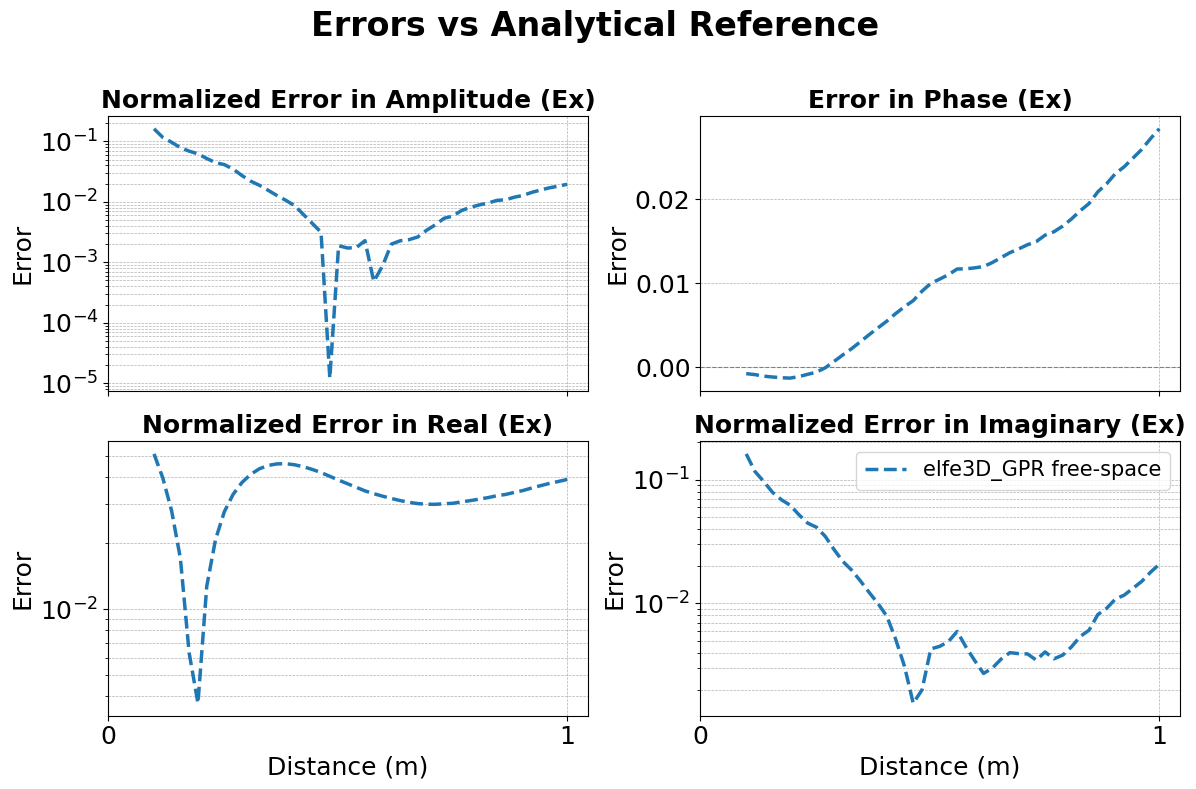

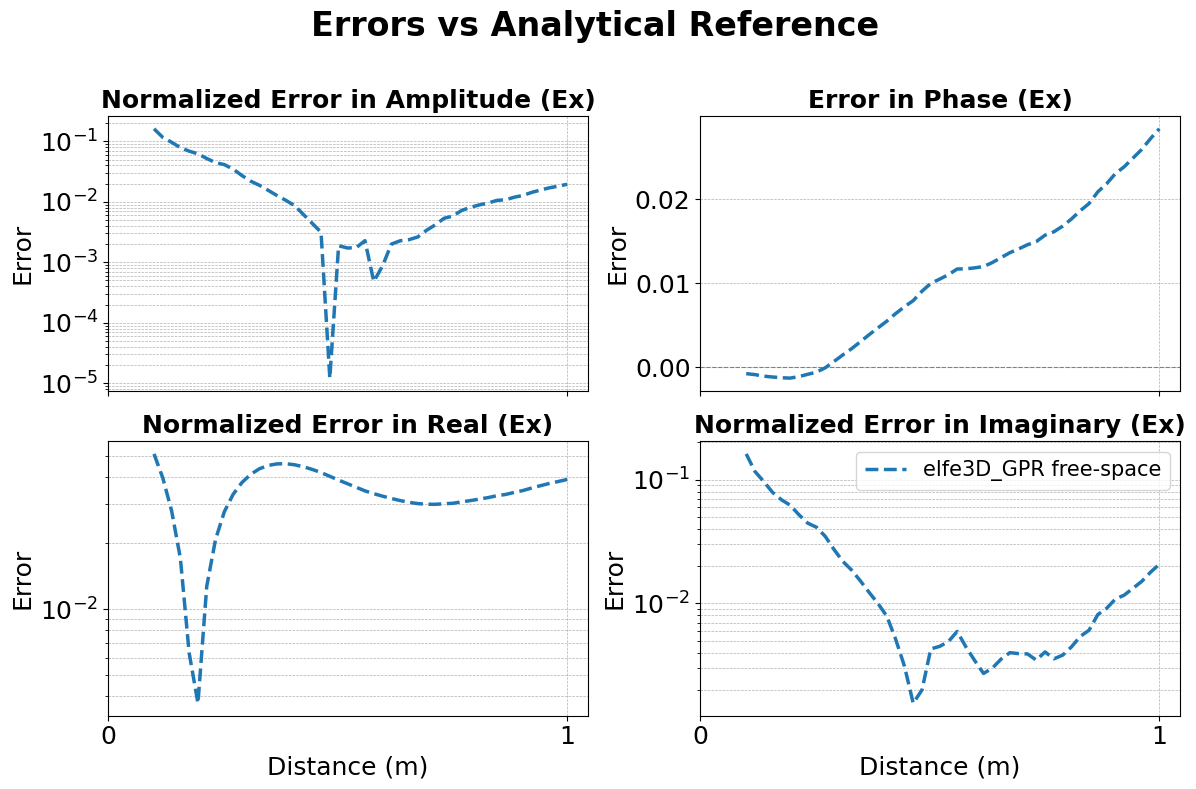

In [8]:
ReceiverLineErrorPlot([ef], reference=analytical).plot(suptitle='Errors vs Analytical Reference') 


Inspecting this, it is clear that there is a sweet spot where the errors are much lower than 1%. Close to the domain boundary, and close to the source, errors are higher. However, this is an understandable numerical approximation error which arises from the unstructured nature of the FEM mesh. Moreover, real world antennas at 100 MHz frequency typically have more separation between the source and receiver.

### 8.3 Combined field and error plot

We can also overlay the default field and error visualizations to inspect the results in one view.

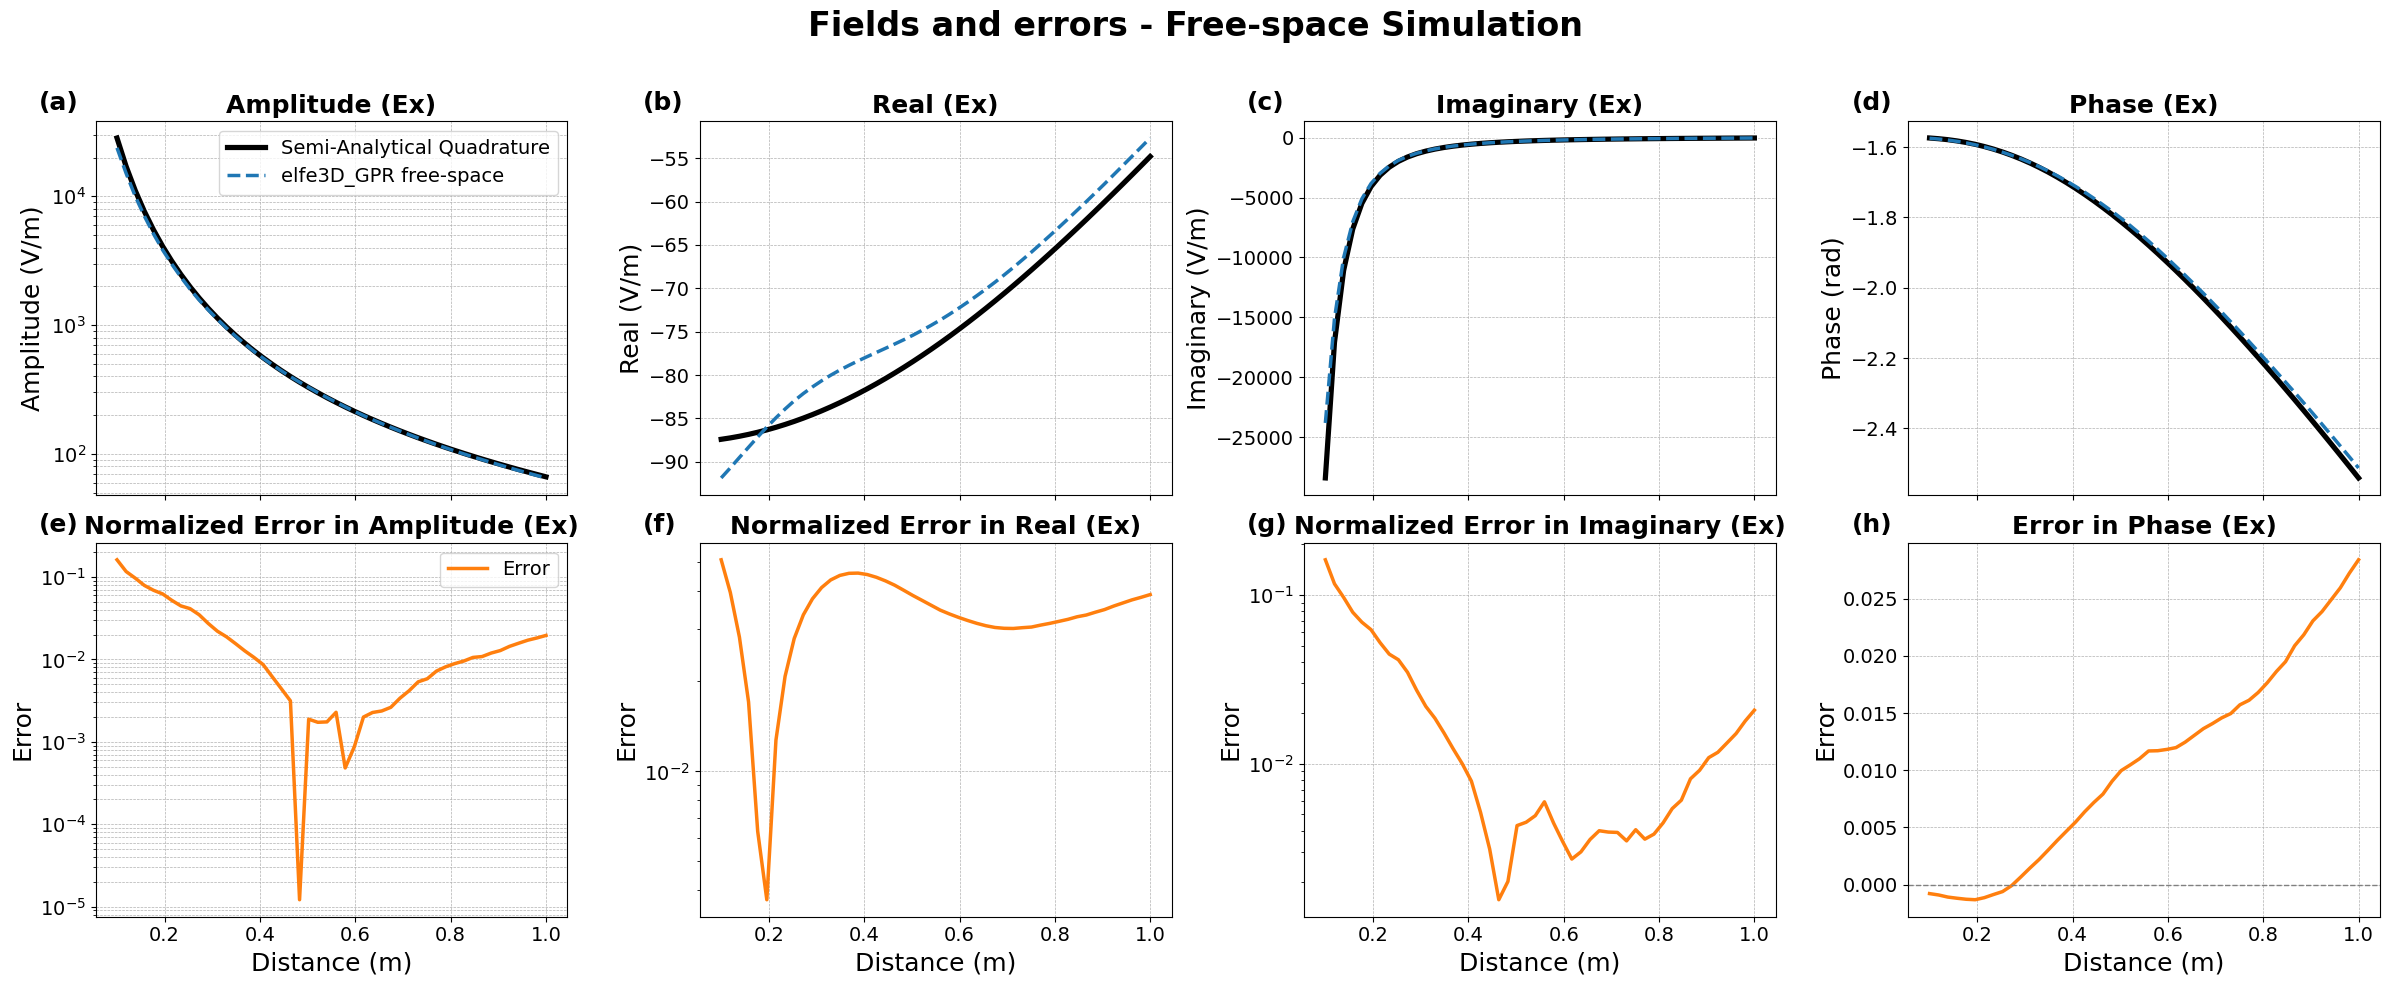

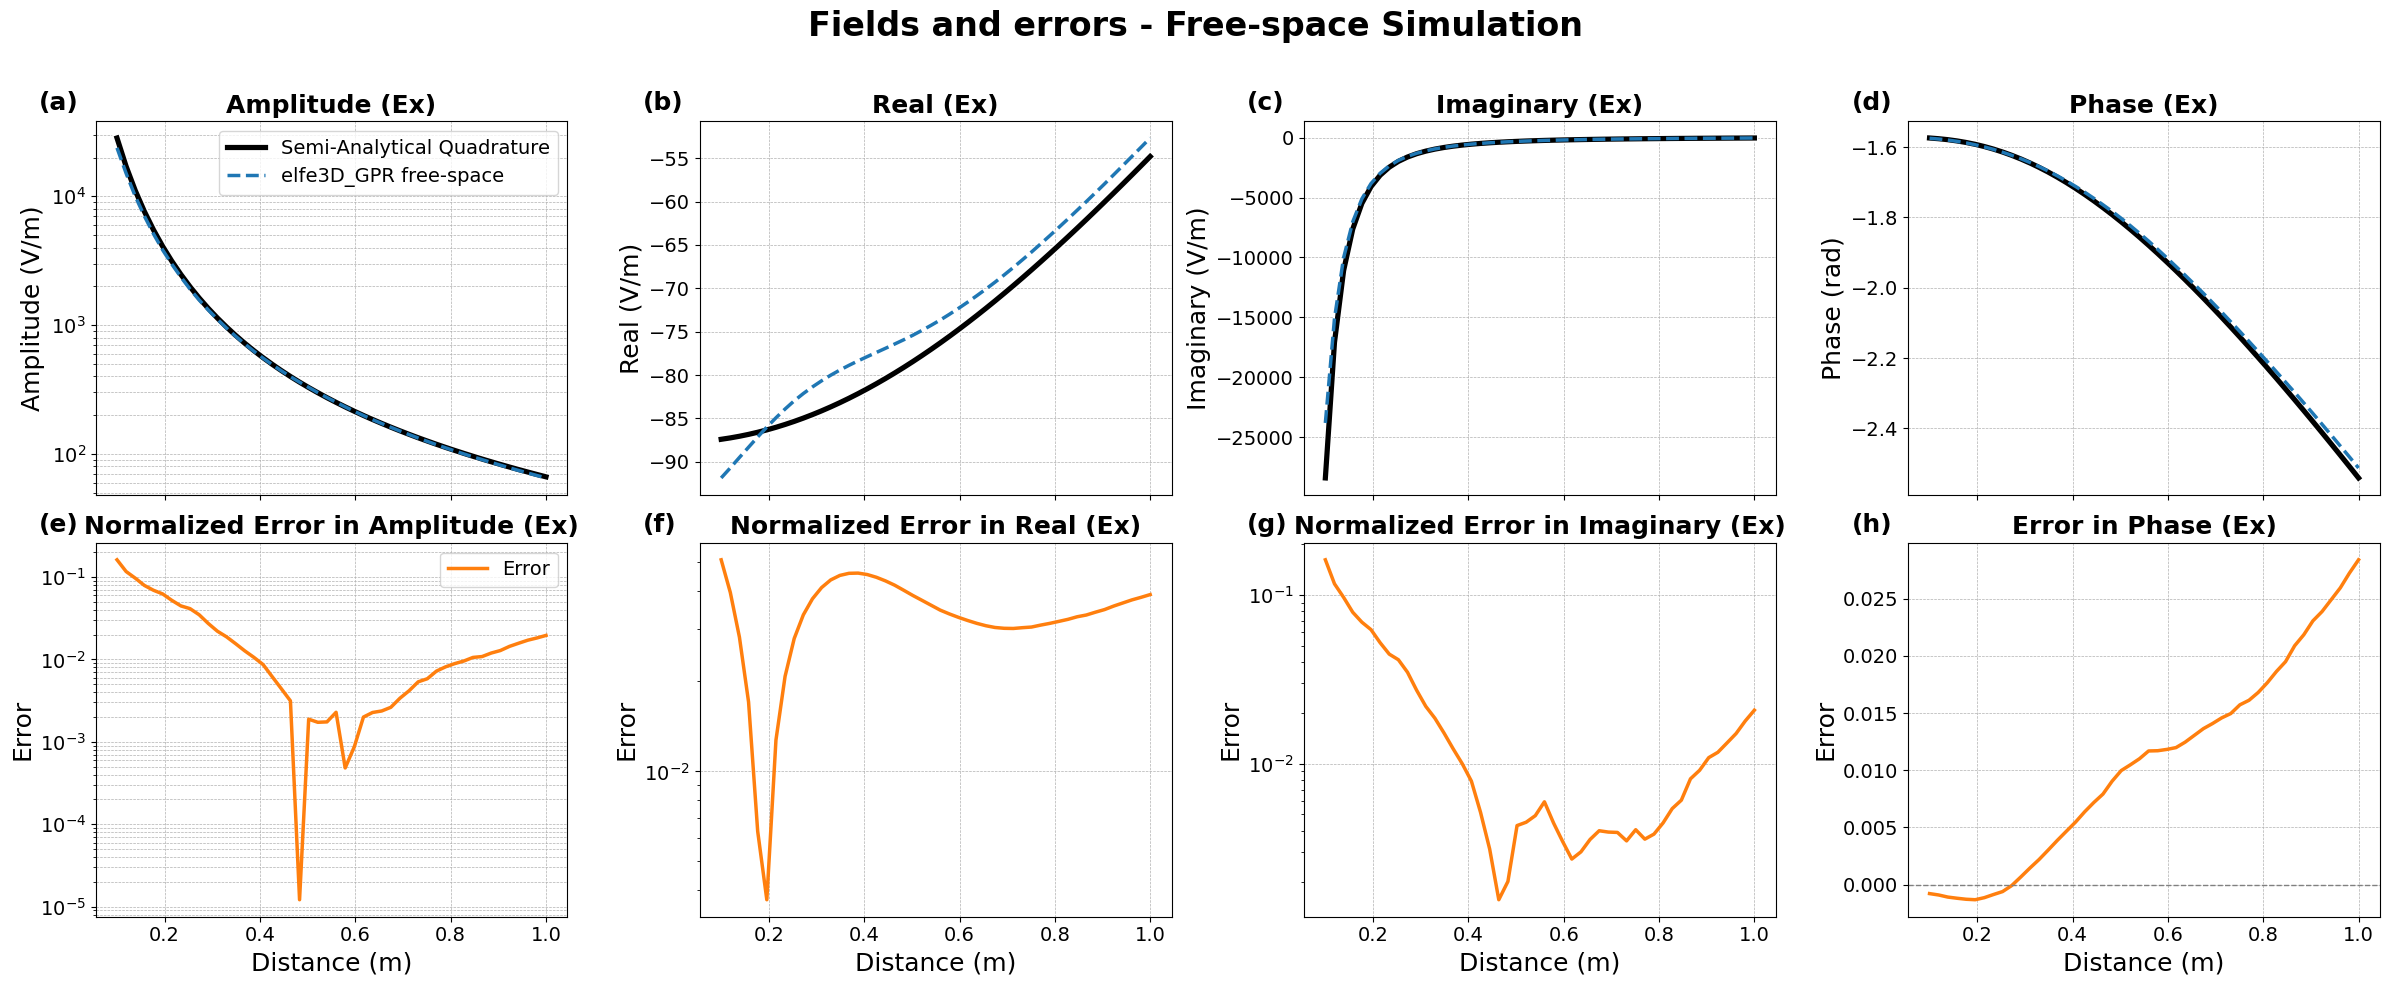

In [9]:
ReceiverLineCombined(ef, analytical).plot(suptitle='Fields and errors - Free-space Simulation')


### 8.4. Error distribution histogram

We can also plot a histogram of errors that shows the distribution of errors relative to the analytical reference. It is useful for identifying systematic bias or large outliers in the computed field.

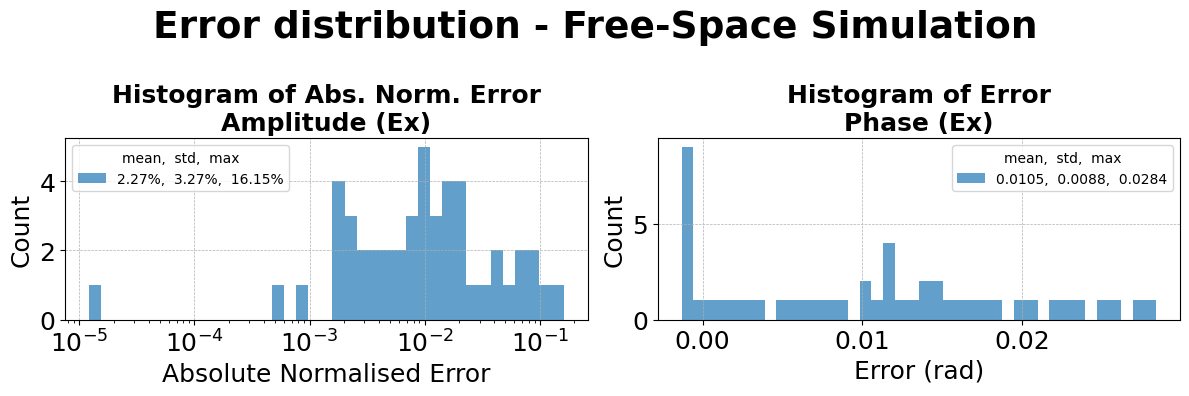

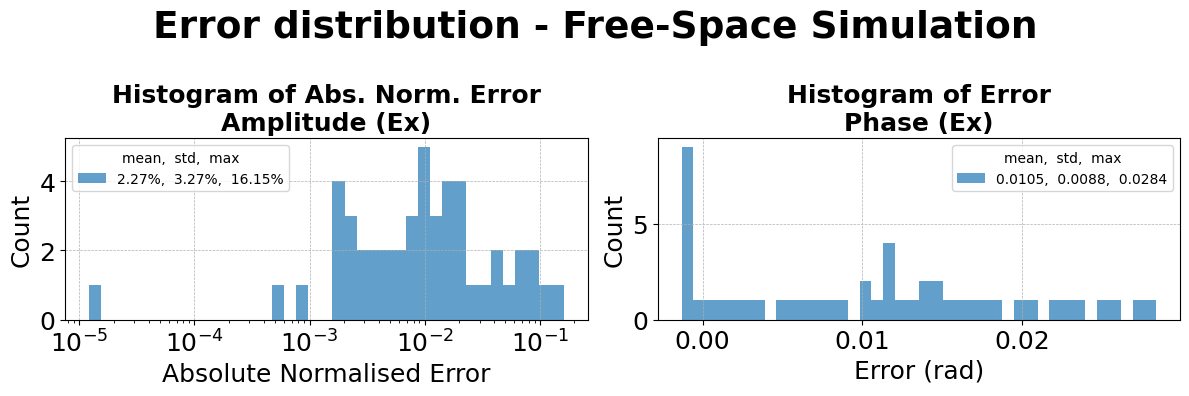

In [10]:
ErrorHistogramPlot([ef], reference=analytical).plot(suptitle='Error distribution - Free-Space Simulation')

These are some preliminary error statistics of the output. With other simulations, we will note how these statistics change.

## 9. Conclusions

This notebook demonstrates the core `elfe3D_GPR` workflow with the Python I/O wrapper for a free-space-only model.
The inputs are generated with the `GPRSurvey` class, and the outputs are analysed. In the next examples of layered and anomalous media, we will cover more geophysical aspects of GPR simulations.